# <span style='color:deepskyblue'> Cosmology MCMC notebook </span>

## <span style='color:deepskyblue'>Preliminaries</span>

In [1]:
# Install required packages (if not available on server, uncomment the lines below)

%pip install --upgrade pip
%pip install getdist
%pip install numpy
%pip install scipy
%pip install matplotlib



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
 #Load required packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.integrate as integrate
%pip install getdist
# import pylab
import getdist, IPython, time
from numpy import random

# from IPython.display import Image
from getdist import plots, MCSamples, loadMCSamples

# just for printing! calculations should be performed with machine precision
%precision 3

Note: you may need to restart the kernel to use updated packages.


'%.3f'

(NB: Those equations that you will need to build your code are those $\boxed{\text{with a box around}}$)

## <span style='color:deepskyblue'> The $\Lambda$CDM Model </span>

The Lambda-Cold-Dark-Matter ($\Lambda$ CDM) Model is our current "Standard" cosmological model. It postulates a Universe that behaves according to **General Relativity**, filled with **baryons** (protons, neutrons - the stuff we and stars are made of!), **Cold Dark Matter (CDM)** and a **Cosmological Constant** $\Lambda$.

The expansion of the Universe is best described in terms of the **scale factor** $a$ (the "radius" of the Universe, conventionally set to 1 today) and the **Hubble rate** $H$

$$
H \equiv \frac{\dot a}{a} 
$$
Where the dot signifies a time derivative $\dot a \equiv da/dt $

The Einstein Equations in a **homogeneous and isotropic** Universe have an especially simple form and a special name, **Friedmann Equation**:

$$
H^2 = \frac{8\pi G}{3}\rho + \frac{k}{a^2}
$$

where $\rho$ is the total energy density of the Universe (at a certain time or size), and $k$ is a universal constant related to the [spatial curvature and shape of the Universe](https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies.). In the $\Lambda$ CDM model (and at late enough times), this additionally simplifies to

$$
\boxed{
H^2 = H_0^2\left(\Omega_\Lambda + \Omega_m a^{-3} + \Omega_k a^{-2}\right)
}
\qquad
\qquad
\boxed{
\Omega_m + \Omega_\Lambda + \Omega_k = 1
}
$$

$H_0$ is the value of the Hubble rate *today*, and the parameters $\Omega_m$, $\Omega_\Lambda$ and $\Omega_k$ are dimensionless quantities indicating how much of the present expansion of the Universe is due to (non-relativistic) matter, cosmological constant $\Lambda$, and spatial curvature $k$. Note that the three $\Omega$'s are *not independent* (their sum is 1) and that we grouped together the contribution of baryons and CDM,

$$
\Omega_m = \Omega_{\rm CDM} + \Omega_{\rm b}
$$

and that we have evidence that independent evidence that $\Omega_b \approx 5$\%. Note that only $\Omega_m \geq 0$ makes physical sense, while in principle both $\Omega_\Lambda$ and $\Omega_k$ can be negative.
In this consideration we are neglecting the contribution of the radiation which becomes negligable after the early stages of expansion.


The present Hubble rate is conventionally parametrised in terms of the dimensionless $h$:

$$
H_0 \equiv h\, \times 100 \left[\frac{ \,\text{km}}{\text{s Mpc}}\right]
$$

where Mpc = Megaparsec and [parsec](https://en.wikipedia.org/wiki/Parsec)  $pc = 3.086 \cdot 10^{16}$ m.

In essence, these equations give us the relation between *what exists in the Universe* and *how the Universe expanded*. Measure one, I can tell you the other. This is precisely what we aim to do!

Time to define the function $H(z)$. Don't forget to include the useful parameters as arguments of the function, and to define `parsec`.

## <span style='color:orange'> Excersise 1 </span>

Write your own code for the Hubble parameter as a function of redshift (z) note that $a = \frac{1}{1+z}$. Make a plot to see if your function works as expected.

In [3]:
pc = 3.086e+16 #defining a parsec

#The next constants were taken from: https://www.sciencedirect.com/science/article/pii/S0370157319300511?ref=pdf_download&fr=RR-2&rr=9d36751ebe2d0b87#sec3

omega_b = 0.044
omaga_CDM = 0.24

h = 0.7
omega_m = omaga_CDM + omega_b

omega_lmbd = 0.72

H_0 = 100 * h # To get the hubble rate in meters, not mega parsecs

# Hubble ratep
def Hubble(z, omega_lmbd, omega_m, oamga_k, H_0):
    H = H_0 * np.sqrt(omega_lmbd + omega_m * (1 + z)**3 + oamga_k * (1 + z)**2)
    return H


So, above I made a lot of global values that I'll never use, and the hubble fuction as asked for above. 

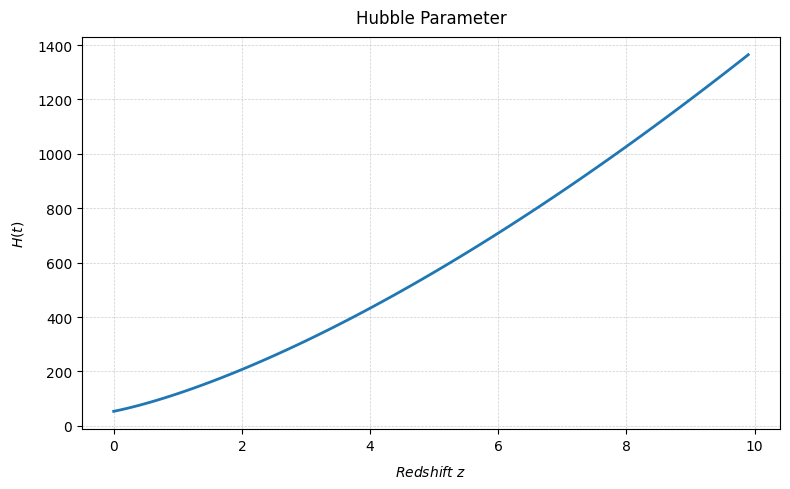

In [4]:
t = np.arange(0,10,.1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t, Hubble(t, .2, omega_m, 0.1, H_0),
    linewidth=2
)
ax.set_xlabel("$Redshift$ $z$", labelpad=8)
ax.set_ylabel("$H(t)$", labelpad=8)
ax.set_title("Hubble Parameter", pad=10)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()

I am still not sure why this means that it works correctly but with the next steps it is ovious that the equation is correct and usable

##  <span style='color:deepskyblue'>Supernovae Ia</span>

In order to track the expansion of the Universe, we will look at Supernovae type Ia observations. SNIa are formed when a *white dwarf* accretes matter from a companion until it reaches a critical mass of about $1.44 M_\odot$ (solar masses), after which it explodes **at always the same luminosity** $L_{\rm SN}$. Therefore, the observed [magnitude](https://en.wikipedia.org/wiki/Magnitude_(astronomy)) is only a function of their [**luminosity distance**](https://en.wikipedia.org/wiki/Distance_measures_(cosmology)) from Earth, defined as the ratio of the intrinsic luminosity $L_{\rm SNIa}$ and the measured *surface brightness* $\Phi$ (energy per unit time per unit area)

$$ d_L\equiv \frac{L_{\rm SN}}{4\pi \Phi} $$

While photons (light rays) travel from the distant SNIa to Earth, the Universe expands and the photons get redshifted, and this redshift is directly related to the size of the Universe when the photon was emitted compared to today:

$$ \frac{\lambda_{\rm obs}}{\lambda_{\rm em}} \equiv 1 + z_{\rm em} = \frac{1}{a_{\rm em}}$$

We can express the luminosity distance in terms of the Hubble rate:

$$
\boxed{
d_L(z) = \frac{c}{H_0}(1+z) \times
\begin{cases}
    \cfrac{1}{\sqrt{\Omega_k}} \,\sinh\left(\sqrt{\Omega_k}\,D(z)\right) & \Omega_k > 0
    \\[.5em]
    D(z) & \Omega_k = 0
    \\[.5em]
    \cfrac{1}{\sqrt{-\Omega_k}} \,\sin\left(\sqrt{-\Omega_k}\,D(z)\right) & \Omega_k < 0
\end{cases}
\qquad\qquad
D(z) \equiv H_0\int_0^z \frac{{\rm d}Z}{H(Z)}
}
$$

where $c$ is the speed of light: $c \simeq 2.998 \cdot 10^{5}$ km/s.

Clearly, there exists a relation between $d_L(z)$ and $H(z)$, so the luminosity distance is a useful measure of the Universe expansion history.

We can create the function `dL(z, h, Omega_m, Omega_Lambda)`. You can also pass the function `Hubble` as an argument: `dL(z, Hubble, Omega_m, Omega_Lambda)`. Additionally, you can create $D(z)$ for your convenience.

Note that you need to integrate the function $H(z)$, so write your own quick-and-easy numerical integrator, for example implementin the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) or your favourite alternative, or [look up the pre-written methods](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html). Make sure it returns $d_L$ in parsecs and that it uses $h$, which is $H_0$ measured in units of 100 km/s/Mpc!

## <span style='color:orange'> Excersise 2 </span>

Define a function that calculate the luminosty distance in flat ($\Omega_k = 0$) and both possitively and negatively curved  ($\Omega_k \neq 0$) spacetime.

In [5]:
from scipy.integrate import quad 

c = 2.998e+5 #write the speed of light in km/s

#((3 * h) / 8) * (f(a) + 3 * f((2 * a + b) / 3) + 3 * f((a + 2 * b) / 3) + f(b));

def int_D(z, step_size, omega_lmbd, omega_m, omega_k, H_0): #Simpson's 3/8 rule, made by me in cpp some time in the past, works dicently in python but it is quite slow
    area = 0
    for i in np.arange(0, z - step_size, step_size):
        a = i
        b = i + step_size
        area = area + ((b - a) / 8) * (Hubble(a, omega_lmbd, omega_m, omega_k, H_0)**(-1)
                                  + 3 * Hubble((2 * a + b) / 3, omega_lmbd, omega_m, omega_k, H_0)**(-1)
                                    + 3 * Hubble((a + 2 * b) / 3, omega_lmbd, omega_m, omega_k, H_0)**(-1)
                                      + Hubble(b, omega_lmbd, omega_m, omega_k, H_0)**(-1))
    return H_0 * area

print(int_D(1, 1e-6, omega_lmbd, omega_m, 0, H_0)) # sanity check, I guess I am at least a little bit sane

def D(z, omega_lmbd, omega_m, omega_k, H_0): # test to see that my function works (it does, though quad astronomically faster)
    integral = H_0 * quad(lambda zp: 1.0 / Hubble(zp, omega_lmbd, omega_m, omega_k, H_0), 0, z)[0]
    return integral


def theor_luminosity_distance(z, H_0, omega_lmbd, omega_m): #d_L using my integer solver
    omega_k = 1 - omega_lmbd - omega_m

    #print(omeg_k) Here I realise that 1-0.7-0.3 is not 0 in python so I remade my functions so they accept just bigger numbers then 1e-8
    
    if omega_k > 1e-8:
        A = 1 / np.sqrt(omega_k) * np.sinh(np.sqrt(omega_k) * int_D(z, 1e-6, omega_lmbd, omega_m, omega_k, H_0))
    else:
        if omega_k < -1e-8:
            arg = np.sqrt(-omega_k) * int_D(z, 1e-6, omega_lmbd, omega_m, omega_k, H_0)

            if arg >= np.pi: # I presume that d_L cannot be negative so this part ignores any number that will make the d_L negative
                return np.nan
            A = 1 / np.sqrt(-omega_k) * np.sin(arg)

        else: A = int_D(z, 1e-6, omega_lmbd, omega_m, 0, H_0)

    d_L = (c / H_0) * (1 + z) * A
    return d_L



def theor_luminosity_distance_quad(z, H_0, omega_lmbd, omega_m):
    omega_k = 1.0 - omega_lmbd - omega_m

    if omega_k > 1e-8:
        A = 1 / np.sqrt(omega_k) * np.sinh(np.sqrt(omega_k)  * D(z, omega_lmbd, omega_m, omega_k, H_0))

    elif omega_k < -1e-8:
        arg = np.sqrt(-omega_k) * D(z, omega_lmbd, omega_m, omega_k, H_0)

        if arg >= np.pi: # I presume that d_L cannot be negative so this part ignores any number that will make the d_L negative
            return np.nan
        A = 1 / np.sqrt(-omega_k) * np.sin(arg)
    else:
        A = D(z, omega_lmbd, omega_m, omega_k, H_0)

    d_L = (c / H_0) * (1 + z) * A
    return d_L if d_L > 0 else np.nan

# Testing the systems
print(theor_luminosity_distance(1, H_0, 0.7, 0.3))

print(theor_luminosity_distance_quad(1, H_0, 0.7, 0.3))

0.7778750409091927
6607.818978323214
6607.823843287365


Here I tried my integer system that I used in cpp for one of my personal projects, unfortunately it is very slow so I just left it there and from now in the future I just fully ignore my system and I use the quad function.
Then, after that we just have the d_L as asked for, whit some safety measures (after spending hours seeing the same wornings I guess I ne)

## <span style='color:deepskyblue'>The Union2.1 Compilation</span>

Our source of data is from [Union2.1](http://supernova.lbl.gov/Union/). It is a collection of $580$ SNIa, each observation is comprised of redshift $z$ and [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus) $\mu$ (and corresponding errors $\delta\mu$), defined as the difference between the *apparent magnitude* $m$ and the *absolute magnitude* $M$:

$$
\boxed{
\mu(z) \equiv m(z) - M \equiv 5 \log_{10} \frac{d_L(z)}{10\,\text{pc}}
}
$$

Our goal today is to use SNIa measurements to constrain the parameters ($h, \Omega_\Lambda, \Omega_m$).

In essence, we can calculate for each redshift the theoretical value of $\mu$ using this equation with the expression for $d_L(z)$ and our model of choice $H(z)$ -- note that we will need to perform a numerical integral! -- and compare this value with observations. A different model would amount to changing the theoretical value of $H(z)$.

Let us start by importing and plotting the data:

In [6]:
import os, io, urllib.request

dataloc = "SCPUnion2.1_mu_vs_z.txt"  # local file
url = "https://web.archive.org/web/2023id_/http://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"     
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})     
response = urllib.request.urlopen(req)     
content = response.read().decode()     
with open(dataloc, 'w') as f:         f.write(content)     
print("Downloaded and saved locally.")


#dataloc = "http://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt"

# Read in data as numpy array.
# Format is [name, redshift, magnitude, magnitude error, and another number?]
data = np.genfromtxt(dataloc)

# Print the first line as an example. (Note that genfromtxt turns the names into 'Not A Number')

Downloaded and saved locally.


Idk what to say here, just copied some stuff from email

In [7]:
display(data)


array([[      nan, 2.849e-02, 3.535e+01, 2.239e-01, 1.284e-01],
       [      nan, 5.004e-02, 3.668e+01, 1.668e-01, 1.284e-01],
       [      nan, 5.293e-02, 3.682e+01, 1.558e-01, 1.284e-01],
       ...,
       [      nan, 8.210e-01, 4.364e+01, 1.940e-01, 5.517e-01],
       [      nan, 1.215e+00, 4.525e+01, 5.603e-01, 1.477e-04],
       [      nan, 6.230e-01, 4.251e+01, 2.414e-01, 5.517e-01]],
      shape=(580, 5))

In [8]:
# Extract the redshifts (zs), distance modulus (dist_mod) and magnitude estimated errors (err_dist_mod)
# Data are in columns, so we either slice it by columns: arr[:,n]...

#zs = data[:,1] # redshift

#print(len(zs))
# ...or transpose the array and then slice by row: arr_transposed[n]


#distance_modulus = data.T[2] # distance modulus
#error_distance_modulus = data.T[3] # errors on distance modulus = sigmas

#I will use the first form such that I will keep the data structure in one palce and I will call each part a number so to be easyer ti remember which is which:
name = 0
redshift = 1
magnitude = 2
magnitude_error = 3 
another_number = 4

zs = data[:,redshift]
d_m = data[:,magnitude]
er_d_m = data[:,magnitude_error]

#In canse one wants to see the data just un-comment these three lines of code:
#display(zs)
#display(d_m)
#display(er_d_m)

I used my own system so to know how it works, at that time I thought I'l need name = 0
redshift = 1
magnitude = 2
magnitude_error = 3 
another_number = 4
I guess not

In [9]:
# Let's look at the data, just for fun.
# We can look both at the raw data (distance modulus) or calculate the luminosity distance
# Note that Numpy allows us to manipulate whole arrays at once with something like:
#     array_2 = some_function_of(array_1)


# I changed the structure of the fucntions a little such that I'll understand the math better. The numbers are the same, just moved them around
# luminosity distance in pc
luminosity_distance_pc = 10**(d_m / 5 + 1)

# and in Mpc
luminosity_distance_Mpc = luminosity_distance_pc * 1e-6

# and the error on that distance:
error_luminosity_distance_Mpc = 5 * (10**((d_m + er_d_m) / 5 ) - 10**((d_m - er_d_m) / 5 )) * 1e-6

Recommendation: plot the data so you can see the luminosity distance and distance modulus as a function of the redshift

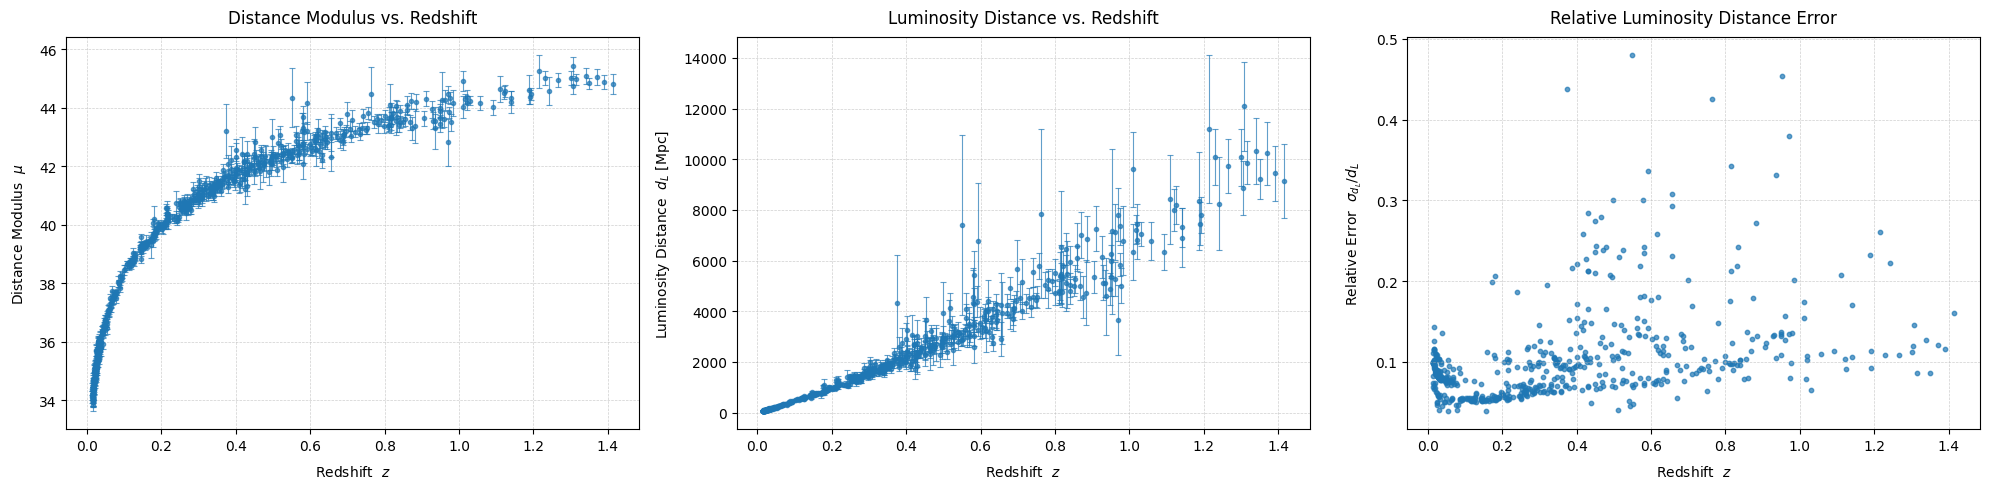

In [10]:
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax1 = axes[0]
ax1.errorbar(zs, d_m, yerr=er_d_m, fmt="o",
    markersize=3, linewidth=0,
    elinewidth=0.8, capsize=2, capthick=0.8,
    alpha=0.7
)
ax1.set_xlabel("Redshift  $z$", labelpad=8)
ax1.set_ylabel("Distance Modulus  $\\mu$", labelpad=8)
ax1.set_title("Distance Modulus vs. Redshift", pad=10)
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

ax2 = axes[1]
ax2.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc, fmt="o",
    markersize=3, linewidth=0,
    elinewidth=0.8, capsize=2, capthick=0.8,
    alpha=0.7
)
ax2.set_xlabel("Redshift  $z$", labelpad=8)
ax2.set_ylabel("Luminosity Distance  $d_L$ [Mpc]", labelpad=8)
ax2.set_title("Luminosity Distance vs. Redshift", pad=10)
ax2.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

ax3 = axes[2]
ax3.scatter(zs, error_luminosity_distance_Mpc / luminosity_distance_Mpc,
    s=10, alpha=0.7
)
ax3.set_xlabel("Redshift  $z$", labelpad=8)
ax3.set_ylabel("Relative Error  $\\sigma_{d_L} / d_L$", labelpad=8)
ax3.set_title("Relative Luminosity Distance Error", pad=10)
ax3.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()

I guess is was fun, as observed above, I made my own system and ploted this stuff, chooes error bars because they look nice :)). The last one was to see what the error is in relation with the data, quite interesting tbh.

## <span style='color:orange'> Excersise 3 </span>

Now also define a function to calculate the distance modulus using your previously defined luminosity distance function. Use these functions to plot the theoretical curves as a function of redshift and compare with the data. (Does the line go through the data points?)

In [11]:
# m - M = 5log_10(d_L) - 5 is the equation for the distance modulus (m - M), information from: https://astronomy.swin.edu.au/cosmos/d/Distance+Modulus

def theor_distance_modulus(z, H_0, omega_lmbd, omega_m): #The theoretical distance modulus using my system 
    d_L = theor_luminosity_distance(z, H_0, omega_lmbd, omega_m)
    d_L = d_L * 1e+6
    return 5 * np.log10(d_L) - 5

def theor_distance_modulus_quad(z, H_0, omega_lmbd, omega_m): #The theoretical distance modulus using quad
    d_L = theor_luminosity_distance_quad(z, H_0, omega_lmbd, omega_m)

    if d_L is None or np.isnan(d_L) or d_L <= 0:
        return np.nan

    d_L = d_L * 1e+6
    return 5 * np.log10(d_L/10)

print(theor_distance_modulus_quad(1,70,.7,.3)) # another sanity check


44.100292283465386


After spending some time on the internet reading I found out that d and d_L are the same thing. I was still trying to use my code, here I realise how slow it is so I stoped using it form here.

Try your functions here. Make atleast two plots to check that for $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$ and $h =0.7$ your theory calculations of the luminosity distance and the distance modulus match okay to the data for redshifts ranging from ~0.1 to 2.

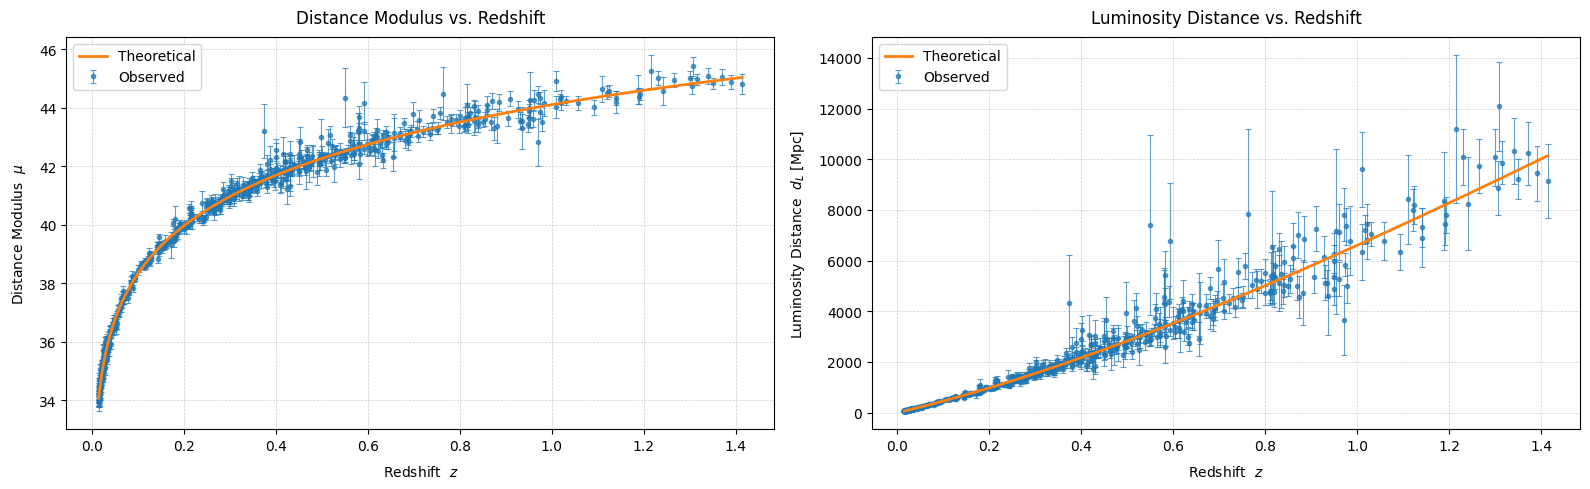

In [12]:
# To be able to use the functions we need to create arrays in which we can put the data
t_d_m = []
t_d_L = [] 

# Writing the constants for this new part
omega_m = .3
omega_lmbd = .7
omega_k = 0
h = 0.7
H_0 = 100 * h


# As we have the arrays, now, here, we add the data from the functions to them
for i in zs:
    t_d_m.append(theor_distance_modulus_quad(i, H_0, omega_lmbd, omega_m))
    t_d_L.append(theor_luminosity_distance_quad(i, H_0, omega_lmbd, omega_m))

# sorting the data so I can make lines in the plot
z = np.array(zs)
d_m_s = np.array(t_d_m)
d_L_s = np.array(t_d_L)

i = np.argsort(z)

zs_s  = z[i]
t_d_m_s = d_m_s[i]
t_d_L_s = d_L_s[i]

# plotting the two figures
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
ax1.errorbar(zs, d_m, yerr=er_d_m, fmt="o",
    markersize=3, linewidth=0,
    elinewidth=0.8, capsize=2, capthick=0.8,
    alpha=0.7, label="Observed"
)
ax1.plot(zs_s, t_d_m_s,
    linewidth=2,
    label="Theoretical", zorder=5
)
ax1.set_xlabel("Redshift  $z$", labelpad=8)
ax1.set_ylabel("Distance Modulus  $\\mu$", labelpad=8)
ax1.set_title("Distance Modulus vs. Redshift", pad=10)
ax1.legend()
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

ax2 = axes[1]
ax2.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc, fmt="o",
    markersize=3, linewidth=0,
    elinewidth=0.8, capsize=2, capthick=0.8,
    alpha=0.7, label="Observed"
)
ax2.plot(zs_s, t_d_L_s,
    linewidth=2,
    label="Theoretical", zorder=5
)
ax2.set_xlabel("Redshift  $z$", labelpad=8)
ax2.set_ylabel("Luminosity Distance  $d_L$ [Mpc]", labelpad=8)
ax2.set_title("Luminosity Distance vs. Redshift", pad=10)
ax2.legend()
ax2.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()

I tried to make the plots have as much information as possible. To be able to make the theoretical data into a line plot I sorted the data by zs. I realised that quad can take just one number at a time so I made a for loop to do the work form me. The rest is history



## <span style='color:deepskyblue'>Bayes' Theorem: Likelihood, Prior, Posterior (and Evidence...)</span>

The **conditional probability of A given that B is true** is denoted with $P(A|B)$ (read: *probability of A given B*).
Did A happen? Then B has probability $P(B|A)$ of happening.

[**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem) is simply a reflection of the symmetry of the concept of joint probability:

$$
P(A|B)P(B) = P(B|A)P(A)
$$

In physics, our goal is often to determine how likely the values of some parameters $\theta$ are, given how well they reproduce the data $D$.
We write Bayes' theorem in the following equivalent form:

$$
P(\theta | D) = \frac{P(D|\theta)P(\theta)}{P(D)}
$$

The various terms conventionally take the names:

$$
\begin{aligned}
P(\theta | D) & && \text{Posterior}
\\
P(D | \theta)& && \text{Likelihood}
\\
P(\theta) & && \text{Prior}
\\
P(D) & && \text{Evidence}
\end{aligned}
$$

### <span style='color:deepskyblue'>Prior</span>

The *prior* quantifies our degree of prior belief in the model parameters. It can contain the results of previous experiments, or theoretical considerations (for instance, that certain parameters cannot be negative, etc.).

We can have *strong priors* about something - the Sun still existing at night, see the comic below - or not.
When we do *not* have compelling prior knowledge about a parameter, we generally use a *non-informative* prior probability distribution, most often related to the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution)

$$
\begin{aligned}
    \text{Uniform} & && \theta \in \text{Uniform}[\theta_{\rm min}, \theta_{\rm max}]
    \\
    \text{Log Uniform} & && \log\theta \in \text{Uniform}[\log\theta_{\rm min}, \log\theta_{\rm max}]
\end{aligned}
$$

You may sometimes hear that "the prior doesn't matter". While this is not strictly true, it is however true that in many instances the *likelihood* depends more dramatically on the parameters and will have a dominating contribution to the posterior. You are more than welcome to try different priors for the model parameters and see if and how your results change.

### <span style='color:deepskyblue'>Likelihood</span>

The measure of how well our model reproduces the data is the **likelihood** $\mathcal L$. For normal (=Gaussian), uncorrelated data $\mu_i$ with errors $\sigma_i$ ($i = \{1,580\}$), the likelihood is related to the famous [**chi-squared**](https://en.wikipedia.org/wiki/Chi-square_distribution) via

$$
P(D | \theta) \equiv \mathcal L = \exp\left(-\frac{\chi^2}{2}\right)
\qquad
\qquad
\boxed{
\chi^2 \equiv \sum_{i=1}^{580} \frac{\left(\mu_i^{(\rm theor)} - \mu_i^{(\rm obs)}\right)^2}{\sigma_i^2}
}
$$

A *high likelihood* corresponds to a *low chi squared*.

In principle, we could attack the problem brute-force: create a grid of values for $h$, $\Omega_m$, $\Omega_\Lambda$, calculate the likelihood for each combination, and create a profile for the likelihood.

In practical cases, however, this is not only sub-optimal but sometimes **impossible**. Think of complicated models with 20+ free parameters (this is not that unusual in physics, by the way). Even a very coarse grained grid of 100 values for each parameter would result in more than$10^{40}$ (!!!) different parameter combination to be tested. You can probably understand why this is undesirable.

### <span style='color:deepskyblue'>Evidence</span>

This is the tricky bit. The evidence, which is "*the probability of observing certain data*", is not something that is easy to evaluate or interpret. This looks like a serious limitation to finding the:


### <span style='color:deepskyblue'>Posterior</span>

What does the data tell us about the model parameters? The answer is the *posterior probability distribution*, often (but not necessarily) expressed as (average $\pm$ standard deviation)

$$
\theta_i = \bar\theta_i \pm \sigma_i
$$

In other words, the posterior tells us how likely it is for the model parameters to have certain values, *given that we observe the data* $D$.

*This is the final goal of our analysis!*

<br>

![title](http://1.bp.blogspot.com/-tTx4HDejSww/ULcTeK9_V_I/AAAAAAAAA8g/PCYOH-eXGbk/s1600/frequentists_vs_bayesians.png)
![title](https://i.redd.it/5r0hwixt0m931.jpg)

## <span style='color:deepskyblue'>Markov-Chain Monte Carlo</span>

Markov-Chain Monte Carlo techniques are a class of methods to sample a probability distribution $P(x)$ - in our case $P(\theta | D)$ - provided that we can calculate a density $\mathcal F(x)$ **that is proportional to it** - in our case $P(\theta)P(D|\theta)$ = likelihood $\times$ prior. Among these, a very popular one is the [**Metropolis-Hastings**](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) algorithm, which is what we will use.

Schematically, the algorithm works as follows:
* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and calculate the $\mathcal F_{\rm old}$
* Propose a new set of parameters $\theta_{\rm prop}$, calculate the new corresponding $\mathcal F_{\rm prop}$. How you propose the new parameters is not essential as long as the probability of going from one set of parameters to the next is the same as the inverse: $P(\theta_a \to \theta_b) = P(\theta_b \to \theta_a)$. For this, we normally take Gaussian displacements with some (relatively small) standard deviation.
* Compare the new and old likelihoods-priors:
    * If $\mathcal F_{\rm prop} > \mathcal F_{\rm old}$, accept the step: $\theta_{\rm new} = \theta_{\rm prop}$
    * Otherwise, accept with probability $P_{\rm accept} = \mathcal F_{\rm prop}/\mathcal F_{\rm old}$
* If accepted, $\theta_{\rm new} = \theta_{\rm prop}$ and record the step; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Update $\theta_{\rm old} = \theta_{\rm new}$
* Repeat

The MC chain keeps going until the desired number of steps or, ideally, when a suitable convergence test, like for example the [Gelman-Rubin test](https://bookdown.org/rdpeng/advstatcomp/monitoring-convergence.html), is satisfied.
Today we will just set a limit to the total number of steps, but please feel free to implement and test your favourite convergence test!

Looking at equation (4), you can convince yourself that
$$
\frac{\mathcal L_a}{\mathcal L_b} = \exp\left(\frac{\chi_b^2 - \chi_a^2}{2}\right)
$$

(This is useful because $\chi^2$ can be large, so we want to avoid the likelihoods evaluating to `0.` -- computers don't like dividing by zero, unfortunately)

* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and the corresponding chi squared $\chi_{\rm old}^2$ (to be clear, for us this implies calculating a series of 580 integrals and comparing each with the observed values)
* Propose new parameters $\theta_{\rm prop}$ and calculate the corresponding chi squared $\chi_{\rm prop}^2$
* Draw a random number $r \in [0,1]$
* Accept the step if
$$
r < \exp\left(\frac{\chi_{\rm old}^2 - \chi_{\rm prop}^2}{2}\right) \frac{P(\theta)_{\rm prop}}{P(\theta)_{\rm old}}
$$
* If accepted, update $\theta_{\rm old} = \theta_{\rm prop}$, and record; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Repeat

##  <span style='color:orange'> Excersise 4 </span>

Write your own code to perform a Monte Carlo Markov Chain. Note that your algorithm should be robust and converge to the correct parameters even for poor initial guesses.

In [21]:
from random import random
from random import gauss
import math

def calculate_chi2(zs, d_m, h, er_d_m, omega_m, omega_lmbd): # The functions as presented above
    t_d_m = []
    H_0 = h * 100

    for i in zs:
        t_d_m.append(theor_distance_modulus_quad(i, H_0, omega_lmbd, omega_m))
    
    if np.any(np.isnan(t_d_m)): #  As t_d_m can be nan we need too ignore them 
        return np.inf

    chi2 = np.sum(((t_d_m - d_m) / er_d_m)**2)
    return chi2 



filename = "MC_Chain_SNIa.txt"
file = open(filename,"w")

# the start parameters
n_h = 0.4
n_omega_m = 0.1
n_omega_lmbd = 0.4

# The change that will be used in the Gauss 
sgm_h = 0.005
sgm_omega_m = 0.005
sgm_omega_lmbd = 0.005


nr_steps = 10000 # the number of steps

chi2_old = calculate_chi2(zs, d_m, n_h, er_d_m, n_omega_m, n_omega_lmbd) #initial chi

N_steps = 0 # to be able to number the steps 

print("Progress: ") # why, not, idk why we have this but sure

start = time.time()

for t in range(1, nr_steps + 1):
    # makig the new valuse for the next chi
    h0  = n_h        + gauss(0.0, sgm_h)
    m0  = n_omega_m  + gauss(0.0, sgm_omega_m)
    l0  = n_omega_lmbd + gauss(0.0, sgm_omega_lmbd)

    
    if m0 <= 0 or h0 <= 0: # to be sure that m0 and h0 are not negative and 
        continue

    chi2_prop = calculate_chi2(zs, d_m, h0, er_d_m, m0, l0) # the next chi

    if random() < np.exp((chi2_old - chi2_prop) / 2) and not math.isinf((np.exp((chi2_old - chi2_prop) / 2))): # as Pprop and Pold are equal (because gauss procentage is the same both ways) we can ignore them. also, for inf we ignore
        # copy the values for the next generation
        n_h = h0
        n_omega_m = m0
        n_omega_lmbd = l0
        chi2_old = chi2_prop

        N_steps += 1
        file.write(f"{n_h:.8f} {n_omega_m:.8f} {n_omega_lmbd:.8f} {chi2_old:.6f}\n") # print the values


file.close()

print("Done! Acceptance ratio = ", N_steps/nr_steps)

end = time.time()
print('time required: {:.2f} s'.format(end-start))

Progress: 


/tmp/ipykernel_9493/507519473.py:56: RuntimeWarning: overflow encountered in exp
  if random() < np.exp((chi2_old - chi2_prop) / 2) and not math.isinf((np.exp((chi2_old - chi2_prop) / 2))): # as Pprop and Pold are equal (because gauss procentage is the same both ways) we can ignore them. also, for inf we ignore


Done! Acceptance ratio =  0.4703
time required: 69.93 s


Here we made the function that calculates chi, took some guesses and made a function that: takes the guess, adds a random number from a gauss distribution that is based around a set of small variations chosen before, it checks if the changes are sane, we can make a new chi with them, check if the new system is acceptable, if yes we can print the data and use the new numbers as the old ones and do that untill you get borred.
Idk why it says overflow, I am just ignoring it and it works so I am happy

After completion of the programme, your MC chain will (*hopefully*) look something like this:

`#Omega_m  Omega_L  h`

`0.297     0.703    0.698`

`0.285     0.715    0.701`

`0.288     0.712    0.699`

`...`

## <span style='color:deepskyblue'>Plotting: GetDist</span>

We will do the plots with [`GetDist`](https://getdist.readthedocs.io/en/latest/plot_gallery.html).

The plot gallery contains a lot of useful examples, you should be able to read them fairly easily and see which applies to your situation. Look for both (triangle) plots and for parameter estimation.

Note that many `GetDist` functions require arguments of type `MCSamples`; make sure you convert your lists accordingly.

##  <span style='color:orange'> Excersise 5 </span>

Use the GetDist functions in the example given underneath but with your **own** MCMC data to generate investigate the sampling of the MCMC.

(3293, 4)
Removed no burn in
0.7  <  h  <  0.7  at  68% CL
0.26  <  OmegaM  <  0.32  at  68% CL
0.7  <  OmegaL  <  0.78  at  68% CL
-0.08  <  Omegak  <  0.02  at  68% CL




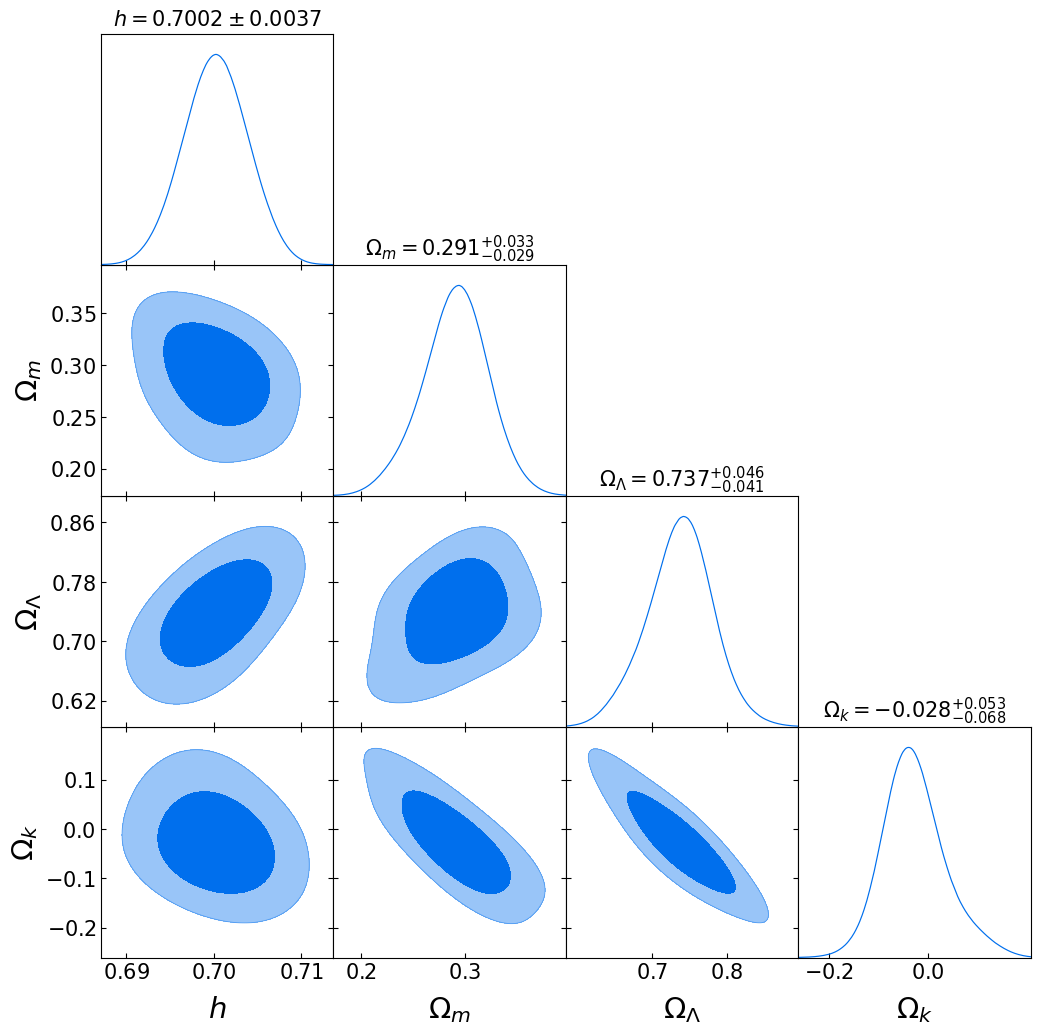

In [22]:
filename = "MC_Chain_SNIa.txt"
datafile = np.loadtxt(filename,
                      skiprows=int(0.3 * N_steps)) # remove some burn-in

h, OmegaM, OmegaL, chi2 = datafile[:,0], datafile[:,1], datafile[:,2], datafile[:,3]

# You can easily create new np.arrays that are functions of other np.arrays
Omegak = 1. - OmegaM - OmegaL

# Let's define variable names and labels
my_labels = [r'h', r'\Omega_m', r'\Omega_\Lambda', r'\Omega_k']
my_names = ['h', 'OmegaM', 'OmegaL', 'Omegak']
my_dim = len(my_names) # The number of variables we're plotting

# This creates a higher-dimensional array with all our data, shaped in the appropriate way...
my_samples = np.transpose(np.reshape([h, OmegaM, OmegaL, Omegak], (my_dim, len(h))))
print(np.shape(my_samples))

# ... to create an "MCSamples" data type, which GetDist can use
my_samples = MCSamples(samples = my_samples, labels = my_labels, names = my_names)

# The usual 1-sigma confidence level. You can change to 2- or 3-sigma if you want
conf_level = 0.6827

# This prints a table with the 1D posteriors (confidence levels)
for nam in my_names:
    print(round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=False),2), \
          " < ", nam , " < ", round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=True),2),\
          " at " , int(100*conf_level),"\b% CL")
print("\n")

#Triangle corner plot
j = plots.getSubplotPlotter(subplot_size=3)
j.settings.axes_labelsize = 22
j.settings.axes_fontsize = 16
j.triangle_plot(my_samples, filled = True, title_limit=1)

In [23]:

print(my_samples.getParamNames())

h	h
OmegaM	\Omega_m
OmegaL	\Omega_\Lambda
Omegak	\Omega_k



Here I do not have comments, plot the data and see if it make sense, without this code I might have spent twice as much time trying to understand why my code was wrong. Thnaks :))

##  <span style='color:orange'> Excersise 6 </span>

Show the curves for $d_L$ and/or $\mu$ as a function of redshift using the best fit parameters determined using your MCMC code, so you will need to make use of your earlier defined functions for $d_L$ and $\mu$ . Check if this correctly reproduces the data. Additionally, provide an extimate on the error and plot the corresponding confidence intervals based on the sample that your MCMC code produces. 

The best:
h:  0.7002304049650774
omega_m:  0.2907922902095354
omega_lmbd:  0.7371817634011539


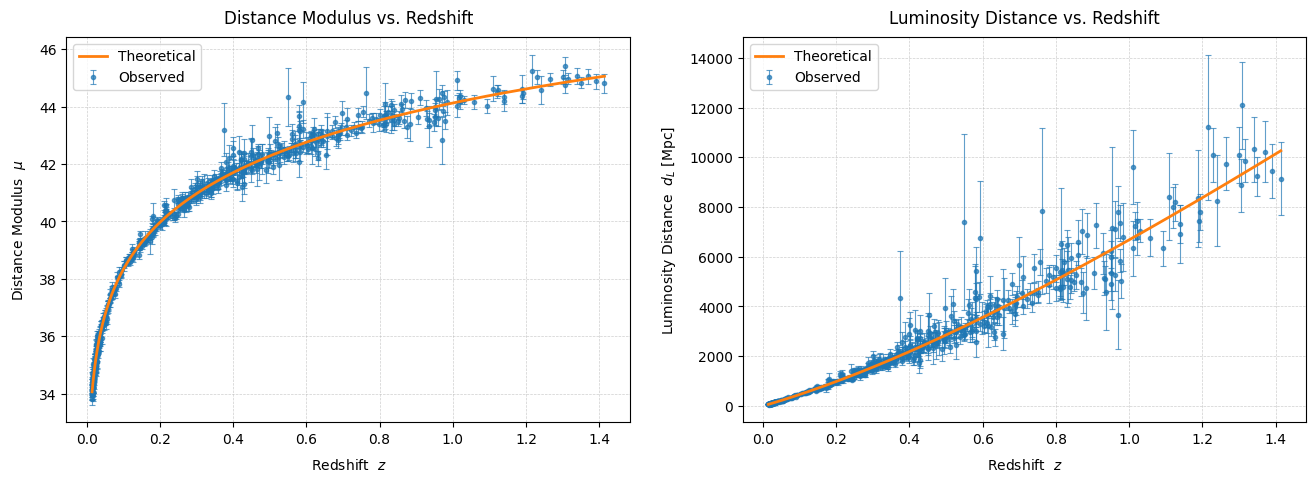

In [24]:

##Example of how to get the confidence intervals from your MCMC samples
h_min = my_samples.confidence('h',(1.-conf_level)/2.,upper=False)
h_max = my_samples.confidence('h',(1.-conf_level)/2.,upper=True)
Omega_M_min = my_samples.confidence('OmegaM',(1.-conf_level)/2.,upper=False)
Omega_M_max = my_samples.confidence('OmegaM',(1.-conf_level)/2.,upper=True)
Omega_L_min = my_samples.confidence('OmegaL',(1.-conf_level)/2.,upper=False)
Omega_L_max = my_samples.confidence('OmegaL',(1.-conf_level)/2.,upper=True)


# stolen from the box of ex. 5
filename = "MC_Chain_SNIa.txt"
datafile = np.loadtxt(filename,
                      skiprows=int(0.3 * N_steps)) # remove some burn-in

h, OmegaM, OmegaL, chi2 = datafile[:,0], datafile[:,1], datafile[:,2], datafile[:,3]

# finding the average
avrg_h = np.mean(h)
avrg_om = np.mean(OmegaM)
avrg_ol = np.mean(OmegaL)


# finding the error 
er_h =np.std(h)
er_m = np.std(OmegaM)
er_l = np.std(OmegaL)



#making the arrays so to be able to plot the theoretical sytems
t_d_m = []
t_d_L = [] 
H_0 = 100 * avrg_h

for i in zs:
    t_d_m.append(theor_distance_modulus_quad(i, H_0, avrg_ol, avrg_om))
    t_d_L.append(theor_luminosity_distance_quad(i, H_0, avrg_ol, avrg_om))



print("The best:")
print("h: ", avrg_h)
print("omega_m: ", avrg_om)
print("omega_lmbd: ", avrg_ol)

# sorting the data so I cam plot lines
z = np.array(zs)
d_m_s = np.array(t_d_m)
d_L_s = np.array(t_d_L)

i = np.argsort(z)

zs_s  = z[i]
t_d_m_s = d_m_s[i]
t_d_L_s = d_L_s[i]

#plotting the data

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0] #fig one
ax1.errorbar(zs, d_m, yerr=er_d_m, fmt="o", 
    markersize=3, linewidth=0,
    elinewidth=0.8, capsize=2, capthick=0.8,
    alpha=0.7, label="Observed"
)
ax1.plot(zs_s, t_d_m_s,
    linewidth=2,
    label="Theoretical", zorder=5
)
ax1.set_xlabel("Redshift  $z$", labelpad=8)
ax1.set_ylabel("Distance Modulus  $\\mu$", labelpad=8)
ax1.set_title("Distance Modulus vs. Redshift", pad=10)
ax1.legend()
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)


ax2 = axes[1] #fig two
ax2.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc, fmt="o",
    markersize=3, linewidth=0,
    elinewidth=0.8, capsize=2, capthick=0.8,
    alpha=0.7, label="Observed"
)
ax2.plot(zs_s, t_d_L_s,
    linewidth=2,
    label="Theoretical", zorder=5
)
ax2.set_xlabel("Redshift  $z$", labelpad=8)
ax2.set_ylabel("Luminosity Distance  $d_L$ [Mpc]", labelpad=8)
ax2.set_title("Luminosity Distance vs. Redshift", pad=10)
ax2.legend()
ax2.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.show()




Here, to make the graphs I just made the average of the data, form what I see it works quite well. Even if I put h = 0.2, omega_m = 0.0 and omega_l = 0.2 it still fits the curve, the numers are weird but it works. h is always quite correct  
I do not understand what what best means here, I'm just using the average.
To be able to make the theoretical data be just a line I sorted the data using zs.